<a href="https://colab.research.google.com/github/httpscaiow/BancoDeDados-CodM3-/blob/main/C1_Projeto_M1_Opera%C3%A7%C3%B5es_Pontuais_e_Filtragem_Espacial_DEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Sinais: Imagens<br>
Professor: Felipe Viel<br>
Alunos: Caio Cardoso; Gabriela Correa

# Projeto M1 – Operações Pontuais e Filtragem Espacial

---


## 1. Importação das Bibliotecas

Nesta etapa importamos todas as dependências necessárias para o projeto.
- `cv2` (OpenCV): usado **apenas** para redimensionar imagens e exibi-las no Colab. Nenhuma função de filtragem do OpenCV é utilizada.
- `numpy`: estrutura de dados para representar as imagens como matrizes numéricas e realizar operações matemáticas.
- `medmnist`: biblioteca que fornece o dataset de imagens médicas MedMNIST v2.
- `matplotlib`: geração de gráficos de histograma para análise de contraste.


In [1]:
# IMPORTAÇÃO DAS BIBLIOTECAS
!pip install medmnist

import cv2                              # Apenas para redimensionamento e exibição (E/S visual)
import numpy as np                      # Operações matemáticas com matrizes
import medmnist                         # Provedor do dataset de imagens médicas
from medmnist import INFO               # Metadados do dataset (nome da classe, canais, etc.)
from google.colab.patches import cv2_imshow  # Exibição de imagens dentro do Colab
import matplotlib.pyplot as plt         # Visualização de histogramas e gráficos


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.4 MB/s eta 0:00:00


## 2. Configuração e Carregamento do Dataset

Utilizamos o **ChestMNIST**, um subconjunto do MedMNIST composto por radiografias de tórax em escala de cinza.
As imagens são carregadas em 224×224 pixels via a biblioteca medmnist e depois convertidas para matrizes NumPy do tipo `float32`, que é o formato ideal para cálculos de intensidade de pixel (evita truncamentos de inteiro durante operações matemáticas).

> **Nota sobre o tamanho:** carregamos as imagens originalmente em **224px** e depois as redimensionamos para **256×256** para o pipeline. Escolhemos 256 em vez de 512 para que o filtro de mediana (que é computacionalmente intenso por ser implementado em Python puro) rode mais rapidamente

In [2]:
# CONFIGURAÇÃO E CARREGAMENTO DO DATASET

# ─────────────────────────────────────────────────────────────────────────────
# FUNÇÃO AUXILIAR: Converte qualquer array de imagem para float32
# Isso garante que operações matemáticas (divisões, potências) sejam precisas
# e não causem truncamentos indesejados (problema comum com uint8).
# ─────────────────────────────────────────────────────────────────────────────
def converter_para_float(img_array):
    """Converte a matriz de imagem para float32 para cálculos precisos."""
    return img_array.astype(np.float32)


# ─── PARÂMETROS GLOBAIS ───────────────────────────────────────────────────────
# Dataset escolhido: ChestMNIST (radiografias de tórax, escala de cinza)
# Outras opções válidas: 'octmnist', 'pathmnist', 'pneumoniamnist'
nome_do_dataset   = 'chestmnist'

# Índices das imagens escolhidas dentro do dataset de treino
indices_escolhidos = [10, 15, 30]

# Tamanho de leitura inicial do medmnist (224px é o maior disponível)
tamanho_de_leitura = 224

# Tamanho final após redimensionamento para o pipeline
# 256×256: equilíbrio entre qualidade visual e velocidade do filtro de mediana manual
dimensao_pipeline = (256, 256)
# ─────────────────────────────────────────────────────────────────────────────


# Carrega os metadados do dataset e instancia a classe leitora correspondente
informacoes_dataset = INFO[nome_do_dataset]
ClasseLeitora       = getattr(medmnist, informacoes_dataset['python_class'])

# Carrega o split de treino (download automático se não existir localmente)
banco_de_dados = ClasseLeitora(split='train', download=True, size=tamanho_de_leitura)


# ─── EXTRAÇÃO E PREPARAÇÃO DAS IMAGENS ───────────────────────────────────────
lista_imagens_originais = []  # Armazenará as imagens prontas para o pipeline

for indice in indices_escolhidos:
    # Extrai a imagem do dataset (retorna objeto PIL + rótulo, ignoramos o rótulo)
    imagem_pil, _ = banco_de_dados[indice]

    # Converte PIL → NumPy array (valores inteiros 0-255)
    imagem_array = np.array(imagem_pil)

    # Se a imagem tiver 3 canais (RGB), converte para escala de cinza
    # Isso garante compatibilidade mesmo com datasets coloridos
    if imagem_array.ndim == 3:
        # Fórmula de luminância padrão (ponderação perceptual dos canais RGB)
        imagem_array = (
            0.299 * imagem_array[:, :, 0] +
            0.587 * imagem_array[:, :, 1] +
            0.114 * imagem_array[:, :, 2]
        )

    # Redimensiona para dimensao_pipeline (256×256) usando interpolação cúbica
    # A interpolação cúbica suaviza a pixelização do upscaling
    imagem_float = converter_para_float(imagem_array)
    imagem_redimensionada = cv2.resize(
        imagem_float, dimensao_pipeline, interpolation=cv2.INTER_CUBIC
    )

    lista_imagens_originais.append(imagem_redimensionada)

print(f"| DATASET  : {nome_do_dataset.upper()}")
print(f"| IMAGENS  : {len(lista_imagens_originais)} carregadas (índices {indices_escolhidos})")
print(f"| TAMANHO  : {dimensao_pipeline[0]}×{dimensao_pipeline[1]} px (pipeline)")
print("_" * 50)


100%|██████████| 3.89G/3.89G [03:27<00:00, 18.8MB/s]


| DATASET  : CHESTMNIST
| IMAGENS  : 3 carregadas (índices [10, 15, 30])
| TAMANHO  : 256×256 px (pipeline)
__________________________________________________


## 3. Adição de Ruído Sal e Pimenta

Para avaliar a eficácia dos filtros, corrompemos artificialmente as imagens com **ruído sal e pimenta**.

**Como funciona:**  
Para cada pixel, sorteamos um número aleatório entre 0 e 1. Se o valor sorteado cair nos primeiros 2,5% da distribuição, o pixel recebe valor 0 (preto = "pimenta"). Se cair nos últimos 2,5%, recebe 255 (branco = "sal"). Isso resulta em 5% dos pixels corrompidos no total.

O ruído sal e pimenta simula defeitos comuns em sensores de imagem médica.


In [3]:
# ADIÇÃO DE RUÍDO SAL E PIMENTA

# Percentual de pixels que serão corrompidos pelo ruído (5% do total)
percentual_de_ruido = 0.05

lista_imagens_ruidosas = []  # Armazenará as cópias com ruído adicionado

for imagem_original in lista_imagens_originais:
    # Trabalhamos sobre uma cópia para não alterar a imagem original
    imagem_com_ruido = imagem_original.copy()

    altura, largura = imagem_com_ruido.shape

    # Geramos uma matriz de números aleatórios do mesmo tamanho da imagem
    # Cada posição receberá um valor entre 0.0 e 1.0
    sorteio_aleatorio = np.random.rand(altura, largura)

    # Pixels sorteados abaixo de 2.5% viram PIMENTA (preto = 0)
    imagem_com_ruido[sorteio_aleatorio < (percentual_de_ruido / 2)] = 0

    # Pixels sorteados acima de 97.5% viram SAL (branco = 255)
    imagem_com_ruido[sorteio_aleatorio > (1 - percentual_de_ruido / 2)] = 255

    lista_imagens_ruidosas.append(imagem_com_ruido)

print(f"Ruído sal e pimenta aplicado ({int(percentual_de_ruido*100)}% dos pixels corrompidos).")


Ruído sal e pimenta aplicado (5% dos pixels corrompidos).


### Visualização: Original vs. Ruidosa



_______________________________________________________
  EXEMPLO 1  [ÍNDICE 10 NO DATASET]
_______________________________________________________

[IMAGEM ORIGINAL]


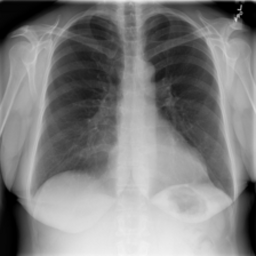


[IMAGEM COM RUÍDO SAL E PIMENTA (5%)]


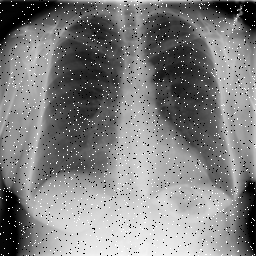


-------------------------------------------------------

_______________________________________________________
  EXEMPLO 2  [ÍNDICE 15 NO DATASET]
_______________________________________________________

[IMAGEM ORIGINAL]


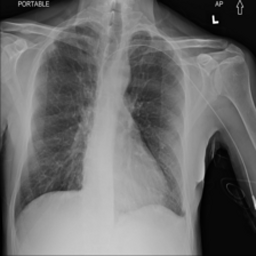


[IMAGEM COM RUÍDO SAL E PIMENTA (5%)]


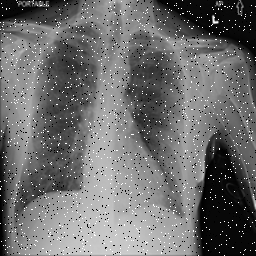


-------------------------------------------------------

_______________________________________________________
  EXEMPLO 3  [ÍNDICE 30 NO DATASET]
_______________________________________________________

[IMAGEM ORIGINAL]


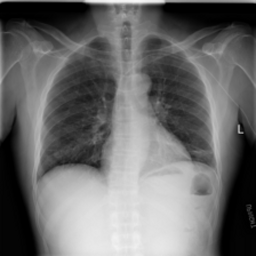


[IMAGEM COM RUÍDO SAL E PIMENTA (5%)]


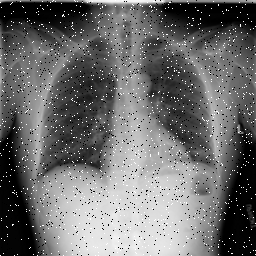


-------------------------------------------------------


In [4]:
# VISUALIZAÇÃO: IMAGENS ORIGINAIS vs. IMAGENS COM RUÍDO

for i in range(len(indices_escolhidos)):
    print(f"\n" + "_"*55)
    print(f"  EXEMPLO {i+1}  [ÍNDICE {indices_escolhidos[i]} NO DATASET]")
    print("_"*55)

    print("\n[IMAGEM ORIGINAL]")
    cv2_imshow(lista_imagens_originais[i])

    print(f"\n[IMAGEM COM RUÍDO SAL E PIMENTA ({int(percentual_de_ruido*100)}%)]")
    cv2_imshow(lista_imagens_ruidosas[i])

    print("\n" + "-"*55)


## 4. Filtragem Espacial – Remoção de Ruído (Filtro de Mediana)

O **filtro de mediana** é um filtro espacial **não-linear** altamente eficaz para remover ruído sal e pimenta sem borrar bordas importantes.

**Como funciona:**  
Para cada pixel da imagem, coletamos seus vizinhos dentro de uma janela (aqui 3×3 = 9 pixels). Ordenamos esses 9 valores do menor para o maior e substituímos o pixel central pelo **valor do meio** (mediana). Pixels extremos (0 ou 255 do ruído) são naturalmente descartados, pois ficam nas pontas da lista ordenada.

**Ordenação por Bubble Sort:**  
Implementamos a ordenação manualmente com Bubble Sort. A cada passagem, o maior valor "borbulha" para o final da lista. Para 9 elementos, o algoritmo é simples e didático.

> **Por que a borda fica preta?**  
> A janela 3×3 não consegue ser aplicada na primeira e última fileira/coluna de pixels sem sair dos limites da matriz. Por isso esses pixels são mantidos como zero (preto). Isso é um comportamento esperado e comum em filtros com bordas não-tratadas.


In [5]:
# FILTRAGEM ESPACIAL NÃO-LINEAR: FILTRO DE MEDIANA COM BUBBLE SORT

def aplicar_filtro_mediana(imagem_ruidosa, tamanho_janela=3):
    """
    Remove ruído sal e pimenta usando o Filtro de Mediana.

    Para cada pixel, coleta os vizinhos em uma janela quadrada,
    os ordena via Bubble Sort e retorna o valor central (mediana).

    Parâmetros:
      imagem_ruidosa  : matriz float32 da imagem com ruído
      tamanho_janela  : lado da janela (padrão 3 = janela 3×3)

    Retorna:
      imagem_filtrada : matriz float32 com o ruído removido
    """
    altura, largura = imagem_ruidosa.shape

    # Margem define quantos pixels de borda não conseguimos processar
    # Para janela 3×3, margem=1 (1 pixel de borda ignorado em cada lado)
    margem = tamanho_janela // 2

    # Criamos a matriz de saída preenchida com zeros
    # Os pixels de borda (margem) permanecerão zero (preto) – comportamento esperado
    imagem_filtrada = np.zeros_like(imagem_ruidosa)

    # Percorremos pixel a pixel, pulando as bordas que a janela não cobre
    for y in range(margem, altura - margem):
        for x in range(margem, largura - margem):

            # ── PASSO 1: CAPTURA DA VIZINHANÇA (janela 3×3) ──────────────────
            # Coletamos os 9 valores de pixels ao redor do pixel central (y, x)
            vizinhanca = []
            for deslocamento_y in range(-margem, margem + 1):
                for deslocamento_x in range(-margem, margem + 1):
                    vizinhanca.append(imagem_ruidosa[y + deslocamento_y, x + deslocamento_x])

            # ── PASSO 2: ORDENAÇÃO POR BUBBLE SORT ───────────────────────────
            # Bubble Sort: a cada passagem, o maior valor "borbulha" para o fim
            # Para N=9 elementos, são no máximo 9 passagens
            total_vizinhos = len(vizinhanca)
            for passagem in range(total_vizinhos):
                for posicao in range(0, total_vizinhos - passagem - 1):
                    if vizinhanca[posicao] > vizinhanca[posicao + 1]:
                        # Troca os dois elementos de posição
                        valor_temp          = vizinhanca[posicao]
                        vizinhanca[posicao]     = vizinhanca[posicao + 1]
                        vizinhanca[posicao + 1] = valor_temp

            # ── PASSO 3: SELEÇÃO DA MEDIANA ───────────────────────────────────
            # O índice do meio da lista ordenada é a mediana
            # Para 9 elementos: índice 4 (0,1,2,3,[4],5,6,7,8)
            indice_mediana = total_vizinhos // 2
            imagem_filtrada[y, x] = vizinhanca[indice_mediana]

    return imagem_filtrada


# ─── APLICAÇÃO DO FILTRO NAS 3 IMAGENS ───────────────────────────────────────
lista_imagens_recuperadas = []  # Armazenará as imagens após remoção de ruído

for i, imagem_ruidosa in enumerate(lista_imagens_ruidosas):
    print(f"Aplicando filtro de mediana na imagem {i+1}/{len(lista_imagens_ruidosas)}...")
    imagem_limpa = aplicar_filtro_mediana(imagem_ruidosa)
    lista_imagens_recuperadas.append(imagem_limpa)

print("\nFiltro de mediana aplicado em todas as imagens.")


Aplicando filtro de mediana na imagem 1/3...
Aplicando filtro de mediana na imagem 2/3...
Aplicando filtro de mediana na imagem 3/3...

Filtro de mediana aplicado em todas as imagens.


### Visualização: Original → Ruidosa → Recuperada (pós-mediana)



____________________________________________________________
   RESULTADO DA FILTRAGEM - EXEMPLO 1 [ÍNDICE 10]
____________________________________________________________

[IMAGEM ORIGINAL]


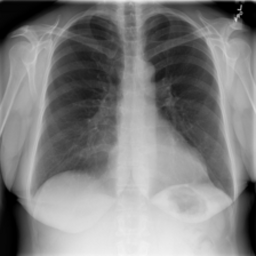


[IMAGEM COM RUÍDO (5% SAL E PIMENTA)]


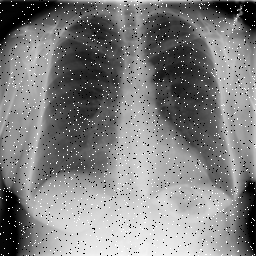


[IMAGEM RECUPERADA — FILTRO DE MEDIANA (BUBBLE SORT, JANELA 3×3)]


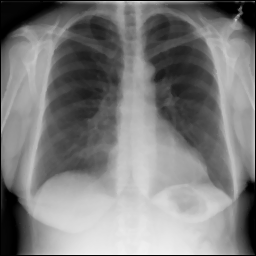


────────────────────────────────────────────────────────────

____________________________________________________________
   RESULTADO DA FILTRAGEM - EXEMPLO 2 [ÍNDICE 15]
____________________________________________________________

[IMAGEM ORIGINAL]


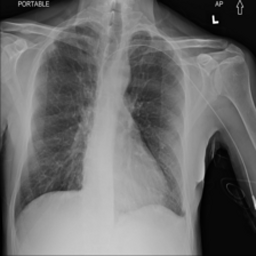


[IMAGEM COM RUÍDO (5% SAL E PIMENTA)]


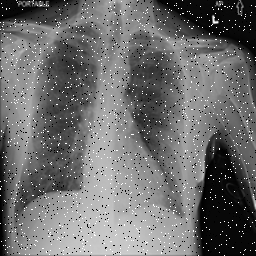


[IMAGEM RECUPERADA — FILTRO DE MEDIANA (BUBBLE SORT, JANELA 3×3)]


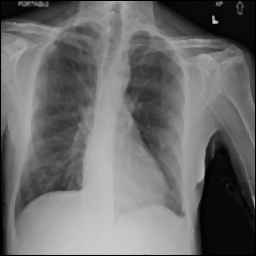


────────────────────────────────────────────────────────────

____________________________________________________________
   RESULTADO DA FILTRAGEM - EXEMPLO 3 [ÍNDICE 30]
____________________________________________________________

[IMAGEM ORIGINAL]


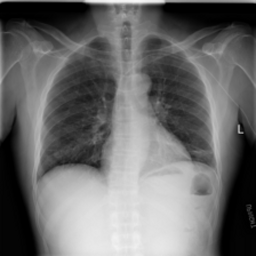


[IMAGEM COM RUÍDO (5% SAL E PIMENTA)]


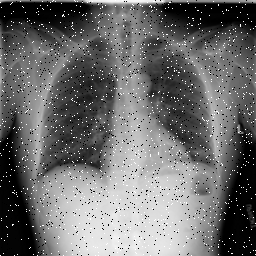


[IMAGEM RECUPERADA — FILTRO DE MEDIANA (BUBBLE SORT, JANELA 3×3)]


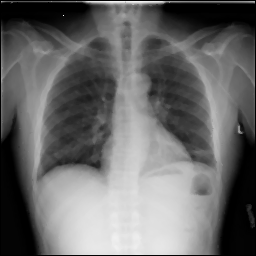


────────────────────────────────────────────────────────────


In [6]:
# VISUALIZAÇÃO: COMPARATIVO ORIGINAL / RUIDOSA / RECUPERADA (MEDIANA)

for i in range(len(indices_escolhidos)):
    print(f"\n" + "_"*60)
    print(f"   RESULTADO DA FILTRAGEM - EXEMPLO {i+1} [ÍNDICE {indices_escolhidos[i]}]")
    print("_"*60)

    print("\n[IMAGEM ORIGINAL]")
    cv2_imshow(lista_imagens_originais[i])

    print(f"\n[IMAGEM COM RUÍDO ({int(percentual_de_ruido*100)}% SAL E PIMENTA)]")
    cv2_imshow(lista_imagens_ruidosas[i])

    print("\n[IMAGEM RECUPERADA — FILTRO DE MEDIANA (BUBBLE SORT, JANELA 3×3)]")
    cv2_imshow(lista_imagens_recuperadas[i])

    print("\n" + "─"*60)


## 5. Operações Pontuais – Ajuste de Contraste

Aplicamos duas técnicas de operação pontual sobre as imagens **recuperadas** (pós-mediana) para melhorar o contraste:

### Pipeline A – Equalização de Histograma
Redistribui os tons de cinza para que a imagem use a faixa completa de intensidades (0–255). O algoritmo calcula a **Função de Distribuição Acumulada (CDF)** do histograma e usa ela como função de mapeamento.  
Fórmula aplicada:  
```
novo_tom = round( (CDF(tom) - CDF_min) / (total_pixels - CDF_min) × 255 )
```
Esta é a fórmula padrão de equalização de histograma, que garante que a CDF resultante se aproxime de uma distribuição uniforme.

### Pipeline B – Correção Gama
Aplica uma transformação não-linear de potência sobre cada pixel:  
```
novo_pixel = (pixel / 255)^γ × 255
```
- γ > 1 → imagem mais escura/contrastada (realça sombras)  
- γ < 1 → imagem mais clara (recupera detalhes em regiões escuras)  
- Usamos γ = 1.2 para um ajuste sutil que aumenta o contraste sem saturar.


In [7]:
# OPERAÇÕES PONTUAIS: EQUALIZAÇÃO DE HISTOGRAMA E CORREÇÃO GAMA

# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE A: EQUALIZAÇÃO DE HISTOGRAMA (fórmula padrão)
# Redistribui os tons para cobrir toda a faixa 0–255 de forma proporcional.
# ─────────────────────────────────────────────────────────────────────────────
def equalizar_histograma(imagem_entrada):
    """
    Equaliza o histograma da imagem usando a CDF (Função Dist. Acumulada).

    A fórmula padrão mapeia cada tom para:
      novo_tom = round( (CDF(tom) - CDF_min) / (N - CDF_min) × 255 )
    onde N = total de pixels da imagem.

    Resultado: imagem com contraste máximo e uso pleno da escala de cinza.
    """
    # Garante que trabalhamos com float32 e valores dentro de [0, 255]
    imagem = np.clip(imagem_entrada, 0, 255).astype(np.float32)
    altura, largura = imagem.shape
    total_de_pixels = altura * largura

    # ── PASSO 1: CALCULAR O HISTOGRAMA ────────────────────────────────────────
    # Contamos quantos pixels existem para cada tom de cinza (0 a 255)
    contagem_por_tom = [0] * 256
    for y in range(altura):
        for x in range(largura):
            tom = int(imagem[y, x])
            contagem_por_tom[tom] += 1

    # ── PASSO 2: CALCULAR A CDF (Soma Acumulada do Histograma) ────────────────
    # A CDF no tom k = soma de todos os pixels com tom ≤ k
    cdf = [0] * 256
    acumulador = 0
    for tom in range(256):
        acumulador += contagem_por_tom[tom]
        cdf[tom] = acumulador

    # Valor mínimo da CDF (primeiro tom que tem ao menos 1 pixel)
    cdf_minimo = min(valor for valor in cdf if valor > 0)

    # ── PASSO 3: MAPEAR CADA PIXEL USANDO A FÓRMULA PADRÃO ───────────────────
    # novo_tom = round( (CDF(tom) - CDF_min) / (N - CDF_min) * 255 )
    imagem_equalizada = np.zeros_like(imagem)
    denominador = total_de_pixels - cdf_minimo

    for y in range(altura):
        for x in range(largura):
            tom_original = int(imagem[y, x])

            if denominador > 0:
                # Fórmula padrão de equalização de histograma
                novo_tom = round((cdf[tom_original] - cdf_minimo) / denominador * 255)
            else:
                # Caso degenerado: imagem completamente uniforme, mantém o tom
                novo_tom = tom_original

            imagem_equalizada[y, x] = novo_tom

    return imagem_equalizada


# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE B: CORREÇÃO GAMA
# Aplica transformação de potência pixel a pixel: saída = (entrada/255)^γ × 255
# ─────────────────────────────────────────────────────────────────────────────
def aplicar_correcao_gama(imagem_entrada, valor_gama=1.2):
    """
    Aplica a correção gama na imagem.

    A fórmula é: saida = (entrada / 255)^γ × 255
    - γ > 1: escurece a imagem, aumenta contraste em tons médios e altos.
    - γ < 1: clareia a imagem, recupera detalhes em sombras.
    - Padrão γ=1.2: realce sutil para imagens médicas (evita saturação).
    """
    imagem = np.clip(imagem_entrada, 0, 255).astype(np.float32)
    altura, largura = imagem.shape
    imagem_corrigida = np.zeros_like(imagem)

    for y in range(altura):
        for x in range(largura):
            # Normaliza para [0, 1], aplica potência γ e volta para [0, 255]
            pixel_normalizado = imagem[y, x] / 255.0
            pixel_corrigido   = np.power(pixel_normalizado, valor_gama)
            imagem_corrigida[y, x] = pixel_corrigido * 255.0

    return imagem_corrigida


# ─── APLICAÇÃO NAS IMAGENS RECUPERADAS (PÓS-MEDIANA) ─────────────────────────
lista_resultados_equalizacao = []  # Resultados do Pipeline A (equalização)
lista_resultados_gama        = []  # Resultados do Pipeline B (gama)

for imagem_recuperada in lista_imagens_recuperadas:
    resultado_equalizacao = equalizar_histograma(imagem_recuperada)
    resultado_gama        = aplicar_correcao_gama(imagem_recuperada, valor_gama=1.2)

    lista_resultados_equalizacao.append(resultado_equalizacao)
    lista_resultados_gama.append(resultado_gama)

print("Equalização de histograma e correção gama aplicadas em todas as imagens.")


Equalização de histograma e correção gama aplicadas em todas as imagens.


### Visualização: Pós-mediana → Equalização → Gama



________________________________________________________________________________
  ANÁLISE DE CONTRASTE — EXEMPLO 1 [ÍNDICE 10]
________________________________________________________________________________

[APÓS FILTRO DE MEDIANA — ENTRADA PARA AS OPERAÇÕES PONTUAIS]


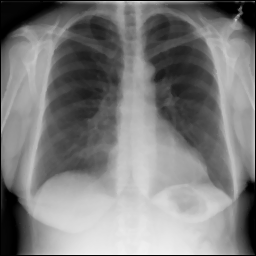


----------------------------------------

[PIPELINE A — EQUALIZAÇÃO DE HISTOGRAMA]


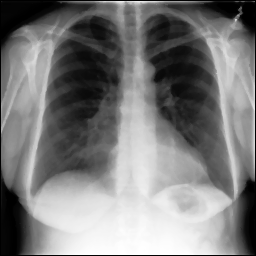


----------------------------------------

[PIPELINE B — CORREÇÃO GAMA (γ = 1.2)]


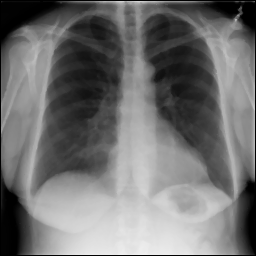


────────────────────────────────────────────────────────────────────────────────

________________________________________________________________________________
  ANÁLISE DE CONTRASTE — EXEMPLO 2 [ÍNDICE 15]
________________________________________________________________________________

[APÓS FILTRO DE MEDIANA — ENTRADA PARA AS OPERAÇÕES PONTUAIS]


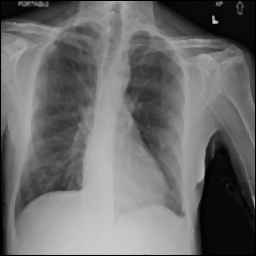


----------------------------------------

[PIPELINE A — EQUALIZAÇÃO DE HISTOGRAMA]


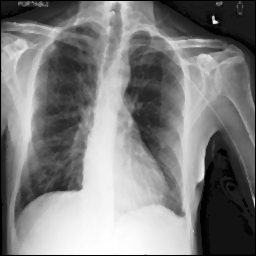


----------------------------------------

[PIPELINE B — CORREÇÃO GAMA (γ = 1.2)]


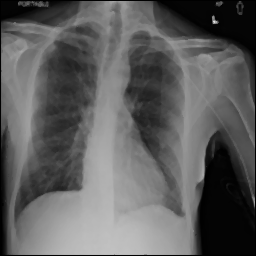


────────────────────────────────────────────────────────────────────────────────

________________________________________________________________________________
  ANÁLISE DE CONTRASTE — EXEMPLO 3 [ÍNDICE 30]
________________________________________________________________________________

[APÓS FILTRO DE MEDIANA — ENTRADA PARA AS OPERAÇÕES PONTUAIS]


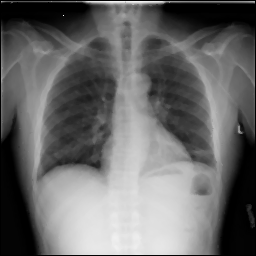


----------------------------------------

[PIPELINE A — EQUALIZAÇÃO DE HISTOGRAMA]


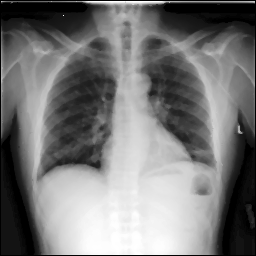


----------------------------------------

[PIPELINE B — CORREÇÃO GAMA (γ = 1.2)]


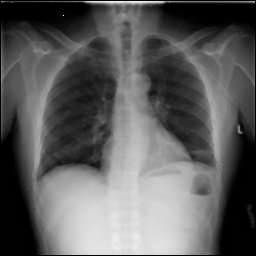


────────────────────────────────────────────────────────────────────────────────


In [8]:
# VISUALIZAÇÃO: COMPARATIVO DAS OPERAÇÕES PONTUAIS DE CONTRASTE

for i in range(len(indices_escolhidos)):
    print(f"\n" + "_"*80)
    print(f"  ANÁLISE DE CONTRASTE — EXEMPLO {i+1} [ÍNDICE {indices_escolhidos[i]}]")
    print("_"*80)

    print("\n[APÓS FILTRO DE MEDIANA — ENTRADA PARA AS OPERAÇÕES PONTUAIS]")
    cv2_imshow(lista_imagens_recuperadas[i])

    print("\n" + "-"*40)

    print("\n[PIPELINE A — EQUALIZAÇÃO DE HISTOGRAMA]")
    cv2_imshow(lista_resultados_equalizacao[i])

    print("\n" + "-"*40)

    print("\n[PIPELINE B — CORREÇÃO GAMA (γ = 1.2)]")
    cv2_imshow(lista_resultados_gama[i])

    print("\n" + "─"*80)


## 6. Filtragem Espacial – Realce de Bordas (Laplaciano + High-Boost)

Após o ajuste de contraste, aplicamos um **filtro de aguçamento** para destacar bordas e estruturas anatômicas.

### Filtro Laplaciano (extração de bordas)
O Laplaciano é um operador de segunda derivada que detecta regiões de variação abrupta de intensidade (bordas). Usamos o kernel de 8-vizinhos:
```
[[-1, -1, -1],
 [-1,  8, -1],
 [-1, -1, -1]]
```
Este kernel tem soma zero, portanto regiões uniformes resultam em saída zero (preto). Apenas transições geram valores positivos.

### High-Boost Filtering (aguçamento final)
O aguçamento não consiste em apenas extrair bordas — é necessário **somar as bordas de volta à imagem original** para realçar o contraste sem perder a estrutura da imagem:
```
g(x,y) = f(x,y) + k × Laplaciano(f(x,y))
```
- k = 1 → Laplaciano padrão  
- k > 1 → High-Boost (realce progressivo)  
- Usamos k = 1.2 para um realce equilibrado.


In [9]:
# FILTRAGEM ESPACIAL LINEAR: LAPLACIANO + HIGH-BOOST FILTERING

def extrair_bordas_laplaciano(imagem_entrada):
    """
    Aplica o kernel Laplaciano 3×3 (8-vizinhos) na imagem.

    O kernel detecta bordas calculando a segunda derivada da intensidade.
    Regiões uniformes → saída zero. Bordas/transições → valores elevados.

    Kernel usado (soma zero, sensível a todas as direções):
      [[-1, -1, -1],
       [-1,  8, -1],
       [-1, -1, -1]]
    """
    # Trabalhamos em float64 para não perder precisão na convolução
    imagem_float = imagem_entrada.astype(np.float64)
    altura, largura = imagem_float.shape

    # Mapa de bordas: inicializado com zeros (bordas de 1px permanecerão zero)
    mapa_de_bordas = np.zeros_like(imagem_float)

    # Kernel Laplaciano 3×3 com 8-vizinhos (detecta bordas em todas as direções)
    kernel_laplaciano = [
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ]

    # Convolução manual: percorremos cada pixel (exceto as bordas)
    for y in range(1, altura - 1):
        for x in range(1, largura - 1):
            soma_convolucao = 0.0
            # Multiplicamos os 9 valores da janela pelo kernel e somamos
            for deslocamento_y in range(3):
                for deslocamento_x in range(3):
                    pixel_vizinho  = imagem_float[y + (deslocamento_y - 1), x + (deslocamento_x - 1)]
                    peso_do_kernel = kernel_laplaciano[deslocamento_y][deslocamento_x]
                    soma_convolucao += pixel_vizinho * peso_do_kernel
            mapa_de_bordas[y, x] = soma_convolucao

    return mapa_de_bordas


def aplicar_high_boost(imagem_entrada, fator_k=1.2):
    """
    Aplica o High-Boost Filtering: combina a imagem original com as bordas.

    Fórmula: g(x,y) = f(x,y) + k × Laplaciano(f(x,y))
    - k = 1.0 → aguçamento Laplaciano padrão
    - k = 1.2 → High-Boost leve (realce equilibrado)
    - k > 2.0 → realce agressivo (risco de saturação)

    O clip final garante que os valores permaneçam em [0, 255].
    """
    imagem_float = imagem_entrada.astype(np.float64)

    # Extrai o mapa de bordas com o Laplaciano
    mapa_de_bordas = extrair_bordas_laplaciano(imagem_float)

    # Soma a imagem original com as bordas ponderadas pelo fator k
    imagem_aguçada = imagem_float + (fator_k * mapa_de_bordas)

    # Garante que os valores permaneçam no intervalo válido [0, 255]
    imagem_aguçada = np.clip(imagem_aguçada, 0, 255)

    return imagem_aguçada.astype(np.float32)


# ─── APLICAÇÃO DO HIGH-BOOST NOS DOIS PIPELINES ───────────────────────────────
# Pipeline A: imagens equalizadas → high-boost
# Pipeline B: imagens com correção gama → high-boost
lista_final_histograma = []  # Resultado final do Pipeline A
lista_final_gama       = []  # Resultado final do Pipeline B

for i in range(len(lista_resultados_equalizacao)):
    resultado_final_A = aplicar_high_boost(lista_resultados_equalizacao[i], fator_k=1.2)
    resultado_final_B = aplicar_high_boost(lista_resultados_gama[i],        fator_k=1.2)

    lista_final_histograma.append(resultado_final_A)
    lista_final_gama.append(resultado_final_B)

print("High-Boost Filtering (k=1.2) aplicado em ambos os pipelines.")


High-Boost Filtering (k=1.2) aplicado em ambos os pipelines.


### Visualização: Resultado Final dos Dois Pipelines



____________________________________________________________________________________________________
  COMPARATIVO FINAL — EXEMPLO 1 [ÍNDICE 10]
____________________________________________________________________________________________________

[PIPELINE A: MEDIANA → EQUALIZAÇÃO DE HISTOGRAMA → HIGH-BOOST]


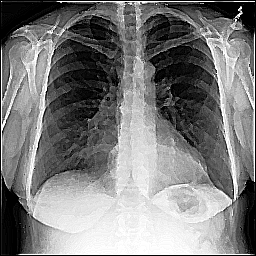


--------------------------------------------------

[PIPELINE B: MEDIANA → CORREÇÃO GAMA (γ=1.2) → HIGH-BOOST]


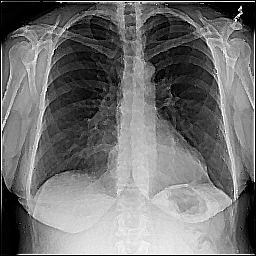


────────────────────────────────────────────────────────────────────────────────────────────────────

____________________________________________________________________________________________________
  COMPARATIVO FINAL — EXEMPLO 2 [ÍNDICE 15]
____________________________________________________________________________________________________

[PIPELINE A: MEDIANA → EQUALIZAÇÃO DE HISTOGRAMA → HIGH-BOOST]


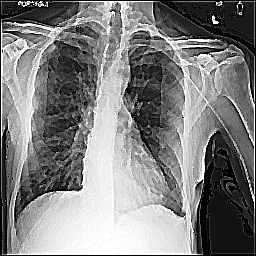


--------------------------------------------------

[PIPELINE B: MEDIANA → CORREÇÃO GAMA (γ=1.2) → HIGH-BOOST]


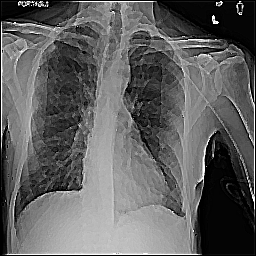


────────────────────────────────────────────────────────────────────────────────────────────────────

____________________________________________________________________________________________________
  COMPARATIVO FINAL — EXEMPLO 3 [ÍNDICE 30]
____________________________________________________________________________________________________

[PIPELINE A: MEDIANA → EQUALIZAÇÃO DE HISTOGRAMA → HIGH-BOOST]


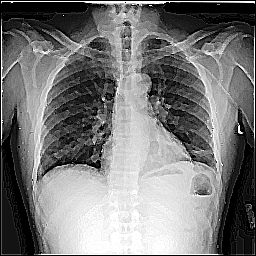


--------------------------------------------------

[PIPELINE B: MEDIANA → CORREÇÃO GAMA (γ=1.2) → HIGH-BOOST]


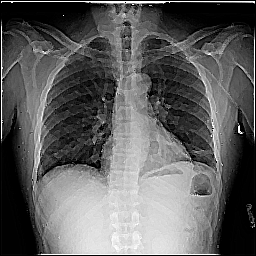


────────────────────────────────────────────────────────────────────────────────────────────────────


In [10]:
# VISUALIZAÇÃO: COMPARATIVO FINAL DOS DOIS PIPELINES

for i in range(len(indices_escolhidos)):
    print(f"\n" + "_"*100)
    print(f"  COMPARATIVO FINAL — EXEMPLO {i+1} [ÍNDICE {indices_escolhidos[i]}]")
    print("_"*100)

    print("\n[PIPELINE A: MEDIANA → EQUALIZAÇÃO DE HISTOGRAMA → HIGH-BOOST]")
    cv2_imshow(lista_final_histograma[i])

    print("\n" + "-"*50)

    print("\n[PIPELINE B: MEDIANA → CORREÇÃO GAMA (γ=1.2) → HIGH-BOOST]")
    cv2_imshow(lista_final_gama[i])

    print("\n" + "─"*100)


## 7. Análise Quantitativa – Métricas MSE e PSNR

Para avaliar objetivamente a qualidade do processamento, utilizamos duas métricas amplamente adotadas em processamento de imagens:

### MSE (Mean Squared Error – Erro Quadrático Médio)
Calcula a média das diferenças ao quadrado entre os pixels da imagem original e da imagem processada:
```
MSE = (1/N) × Σ (original(i) - processada(i))²
```
- **MSE = 0** → imagens idênticas  
- **MSE menor** → imagem processada mais próxima da original  
- **MSE maior** → maior distorção introduzida

### PSNR (Peak Signal-to-Noise Ratio – Relação Sinal-Ruído de Pico)
Expressa a qualidade em decibéis (dB), relacionando o sinal máximo possível com o ruído (erro):
```
PSNR = 20 × log₁₀(255 / √MSE)   [dB]
```
- **PSNR maior** → melhor qualidade de restauração  
- Valores típicos: abaixo de 20 dB (baixa qualidade), 20–30 dB (qualidade razoável), acima de 30 dB (boa qualidade)  
- O PSNR complementa o MSE por expressar o resultado numa escala logarítmica mais intuitiva

### Como interpretar a tabela
Comparamos três estágios em relação à imagem original sem ruído:
1. **Ruidosa**: imagem logo após adicionar o ruído sal e pimenta (linha de base do problema)
2. **Pipeline A**: após mediana + equalização de histograma + high-boost
3. **Pipeline B**: após mediana + correção gama + high-boost

Espera-se que o PSNR dos pipelines seja **maior** que o da imagem ruidosa — isso indica que o processamento de fato recuperou qualidade em relação ao ruído. O pipeline com maior PSNR (e menor MSE) se aproxima mais da imagem original.


In [11]:
# ANÁLISE QUANTITATIVA: MÉTRICAS MSE E PSNR

def calcular_mse_e_psnr(imagem_referencia, imagem_processada):
    """
    Calcula MSE e PSNR entre uma imagem de referência e uma imagem processada.

    MSE  = média de (referência - processada)² para todos os pixels
    PSNR = 20 × log10(255 / sqrt(MSE))  [em decibéis]

    Retorna:
      (mse, psnr) — float, float
      Se MSE = 0 (imagens idênticas), retorna (0, 100) por convenção.
    """
    # Garante que ambas estão no mesmo tipo para a subtração
    referencia  = imagem_referencia.astype(np.float64)
    processada  = imagem_processada.astype(np.float64)

    # MSE: média das diferenças ao quadrado
    mse = np.mean((referencia - processada) ** 2)

    # Caso especial: imagens idênticas (MSE = 0 → PSNR = infinito, convencionamos 100 dB)
    if mse == 0:
        return 0.0, 100.0

    # PSNR em decibéis (valor máximo de pixel = 255 para escala de cinza 8 bits)
    valor_maximo_pixel = 255.0
    psnr = 20 * np.log10(valor_maximo_pixel / np.sqrt(mse))

    return mse, psnr


# ─── CÁLCULO E EXIBIÇÃO DA TABELA DE MÉTRICAS ────────────────────────────────
print(f"{'AMOSTRA':<10} | {'MÉTRICA':<10} | {'RUIDOSA':<16} | {'PIPELINE A':<16} | {'PIPELINE B':<16}")
print("-" * 80)

# Listas para guardar os valores e usar na análise automática abaixo
todos_psnr_ruido = []
todos_psnr_A     = []
todos_psnr_B     = []

for i in range(len(indices_escolhidos)):
    # Compara cada estágio com a imagem original sem ruído
    mse_ruido, psnr_ruido = calcular_mse_e_psnr(lista_imagens_originais[i], lista_imagens_ruidosas[i])
    mse_A,     psnr_A     = calcular_mse_e_psnr(lista_imagens_originais[i], lista_final_histograma[i])
    mse_B,     psnr_B     = calcular_mse_e_psnr(lista_imagens_originais[i], lista_final_gama[i])

    todos_psnr_ruido.append(psnr_ruido)
    todos_psnr_A.append(psnr_A)
    todos_psnr_B.append(psnr_B)

    print(f"Exemplo {i+1}   | MSE        | {mse_ruido:<16.2f} | {mse_A:<16.2f} | {mse_B:<16.2f}")
    print(f"Exemplo {i+1}   | PSNR (dB)  | {psnr_ruido:<16.2f} | {psnr_A:<16.2f} | {psnr_B:<16.2f}")
    print("-" * 80)


# ─── ANÁLISE AUTOMÁTICA DOS RESULTADOS ───────────────────────────────────────
print("\n" + "═" * 80)
print("  ANÁLISE DOS RESULTADOS")
print("═" * 80)

media_psnr_ruido = sum(todos_psnr_ruido) / len(todos_psnr_ruido)
media_psnr_A     = sum(todos_psnr_A)     / len(todos_psnr_A)
media_psnr_B     = sum(todos_psnr_B)     / len(todos_psnr_B)

print(f"\n  PSNR médio — Imagem Ruidosa : {media_psnr_ruido:.2f} dB")
print(f"  PSNR médio — Pipeline A     : {media_psnr_A:.2f} dB")
print(f"  PSNR médio — Pipeline B     : {media_psnr_B:.2f} dB")

# Verifica se os pipelines melhoraram em relação ao ruído
melhora_A = media_psnr_A - media_psnr_ruido
melhora_B = media_psnr_B - media_psnr_ruido

print(f"\n  Ganho de PSNR — Pipeline A vs. Ruidosa : {melhora_A:+.2f} dB", end="")
print(" ✓ (recuperou qualidade)" if melhora_A > 0 else " ✗ (introduziu distorção)")

print(f"  Ganho de PSNR — Pipeline B vs. Ruidosa : {melhora_B:+.2f} dB", end="")
print(" ✓ (recuperou qualidade)" if melhora_B > 0 else " ✗ (introduziu distorção)")

# Indica qual pipeline ficou mais próximo da original
if media_psnr_A > media_psnr_B:
    print(f"\n  ► Pipeline A (Equalização) resultou em maior fidelidade à imagem original.")
    print(f"    Diferença média: {media_psnr_A - media_psnr_B:.2f} dB a favor do Pipeline A.")
elif media_psnr_B > media_psnr_A:
    print(f"\n  ► Pipeline B (Correção Gama) resultou em maior fidelidade à imagem original.")
    print(f"    Diferença média: {media_psnr_B - media_psnr_A:.2f} dB a favor do Pipeline B.")
else:
    print(f"\n  ► Ambos os pipelines apresentaram desempenho equivalente.")

print()
print("  NOTA SOBRE A INTERPRETAÇÃO:")
print("  O PSNR mede fidelidade pixel a pixel à imagem original SEM ruído.")
print("  Um PSNR mais alto indica menor distorção total, mas não captura")
print("  ganhos perceptuais de contraste e nitidez de bordas — que devem")
print("  ser avaliados visualmente nas imagens exibidas acima.")
print("═" * 80)


AMOSTRA    | MÉTRICA    | RUIDOSA          | PIPELINE A       | PIPELINE B      
--------------------------------------------------------------------------------
Exemplo 1   | MSE        | 1036.39          | 1184.62          | 950.53          
Exemplo 1   | PSNR (dB)  | 17.98            | 17.40            | 18.35           
--------------------------------------------------------------------------------
Exemplo 2   | MSE        | 962.22           | 2096.37          | 826.09          
Exemplo 2   | PSNR (dB)  | 18.30            | 14.92            | 18.96           
--------------------------------------------------------------------------------
Exemplo 3   | MSE        | 1079.50          | 1234.15          | 848.63          
Exemplo 3   | PSNR (dB)  | 17.80            | 17.22            | 18.84           
--------------------------------------------------------------------------------

════════════════════════════════════════════════════════════════════════════════
  ANÁLISE DOS RESULTA